In [52]:
#!pip install sentence-transformers

What subset of transformers models would be best to try?

How about a set of experiments with different number length too. So dataset1 includes numbers 0-10, dataset2 0-100, and so on.
Then, let's compare performance between number vs spell-out.
- I think it also had trouble with floats?


I'm thinking... in the pipeline of experiments... apart from different transformers, maybe distances to the embeddings can be tested? Like the method for each, like L2 and other distances ETC.

BERT-base-uncased collapses to 0 for everything except 30, which it guesses correctly.
BERT-base-cased collapses to 52 for everything.

# Cleaned notebook

In [53]:
import pathlib
from dataset_writing import generate_sentence, load_sentences
from experiment import run_experiment
from plots import *
from models import SentenceEncoder
import pandas as pd

In [54]:
MODELS = {
  "MiniLM-L6": "all-MiniLM-L6-v2",
  "mpnet": "all-mpnet-base-v2",
  "BERT-nli-mean-tokens": "bert-base-nli-mean-tokens",
  "BERT-base-uncased": "bert-base-uncased",
  "BERT-base-cased": "bert-base-cased",
  #"BERT-large": "bert-large-uncased",
  "RoBERTa": "all-roberta-large-v1",
    "MiniLM-L12": "all-MiniLM-12-v2",
}

In [55]:
model_name = MODELS["RoBERTa"]
DATASET_FILE = pathlib.Path("../data/ages.txt")
AGE_RANGE = range(0, 100)
PCA_DIMS = 30
TSNE_PERPLEXITY = 20 # check the method to define the best perplexity.

In [56]:
encoder = SentenceEncoder(model_name)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

C:\Users\Ricardo\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Ricardo\.cache\huggingface\hub\models--sentence-transformers--all-roberta-large-v1. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

In [57]:
out_dir = pathlib.Path(f"../results/{model_name}")
out_dir.mkdir(parents=True, exist_ok=True)

In [58]:
#generate_sentence() # already generated.
sentences = load_sentences(path=DATASET_FILE)

Number of sentences: 100
['My age is 91', 'My age is 94', 'My age is 27', 'My age is 85', 'My age is 67', 'My age is 84', 'My age is 71', 'My age is 85', 'My age is 61', 'My age is 78']


In [59]:
results = run_experiment(encoder, sentences, ages = AGE_RANGE)

In [60]:
df_points = pd.DataFrame({
    "age": list(AGE_RANGE),
    "true": results["true"],
    "pred": results["pred"],
    "error": results["errors"],
    "within_+-2": results["correct"],
    "full_error": results["full_error"],
})

csv_path = out_dir / f"{model_name}_results.csv"
df_points.to_csv(csv_path, index=False)
print("Saved results to {}".format(csv_path))

Saved results to ..\results\all-roberta-large-v1\all-roberta-large-v1_results.csv


In [61]:
summary = pd.DataFrame([{
    "model": model_name,
    "accuracy": results["accuracy"],
    "exact_match_acc": results["exact_match_acc"]
}])

summary_path = out_dir / f"{model_name}_summary.csv"
summary.to_csv(summary_path, index=False)

print("Summary saved to {}".format(summary_path))

Summary saved to ..\results\all-roberta-large-v1\all-roberta-large-v1_summary.csv


In [62]:
# If you want to re-do the graphs without having to re-run the experiments.

"""df_points  = pd.read_csv(csv_path)

results = {
    "true":       df_points["true"].tolist(),
    "pred":       df_points["pred"].tolist(),
    "errors":     df_points["error"].tolist(),
    "correct":    df_points["within_+-2"].tolist(),
    "full_error": df_points["full_error"].tolist(),
    "exact_match_acc": df_points["exact_match_acc"].tolist()
}"""

'df_points  = pd.read_csv(csv_path)\n\nresults = {\n    "true":       df_points["true"].tolist(),\n    "pred":       df_points["pred"].tolist(),\n    "errors":     df_points["error"].tolist(),\n    "correct":    df_points["within_+-2"].tolist(),\n    "full_error": df_points["full_error"].tolist(),\n    "exact_match_acc": df_points["exact_match_acc"].tolist()\n}'

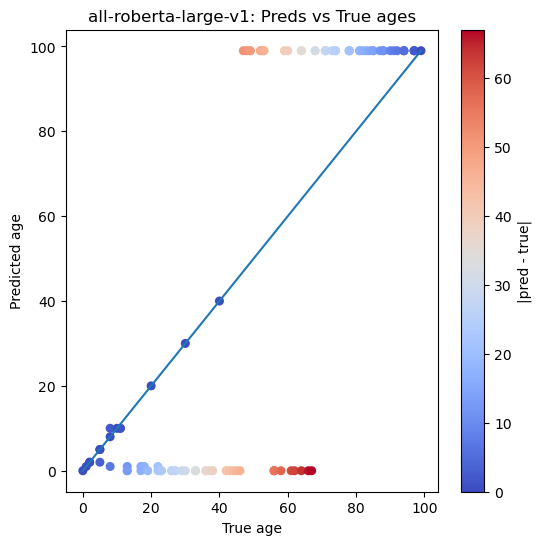

In [63]:
plot_concentration(model_name, out_dir, results['true'], results['pred'], results['errors'])

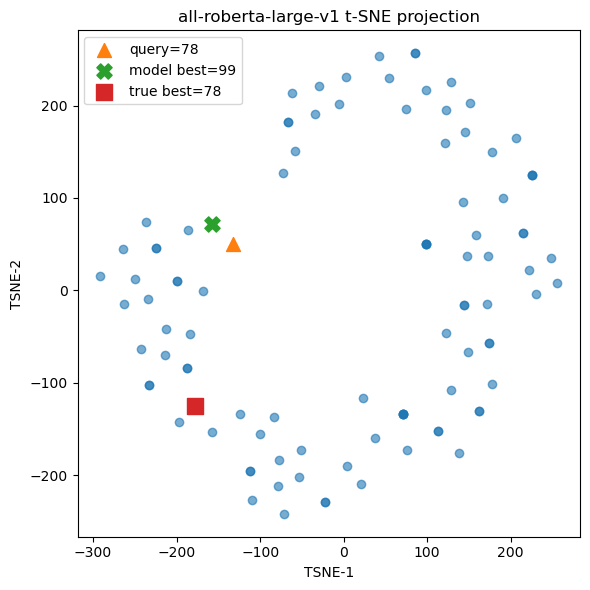

In [64]:
plot_tsne(model_name, out_dir,
          78,
          sentences=sentences,
          encoder=encoder,
          pca_dims=PCA_DIMS,
          perp=TSNE_PERPLEXITY
          )

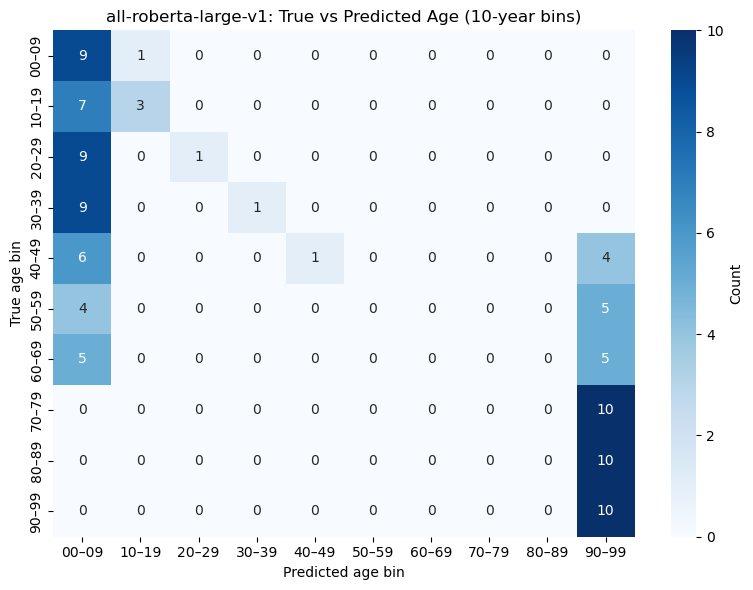

In [65]:
heatmap(results, model_name, out_dir)

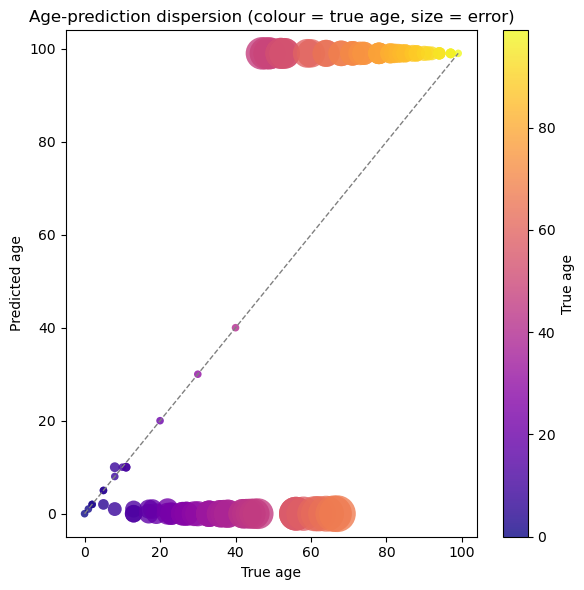

In [66]:
plot_concentration_color_gradient(results, model_name, out_dir)

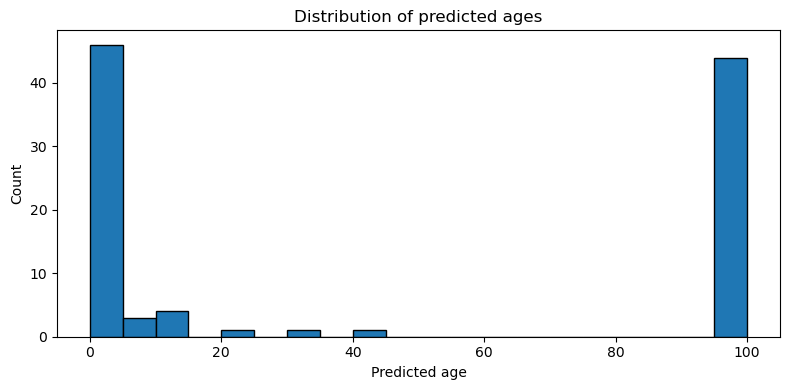

In [67]:
plot_prediction_histogram(results["pred"], bins=range(0,101,5), model_name=model_name, out_folder=out_dir)

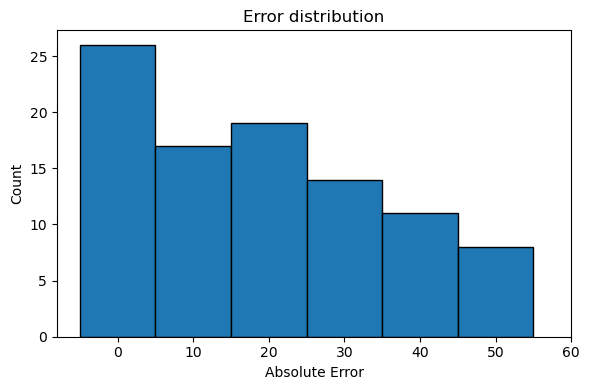

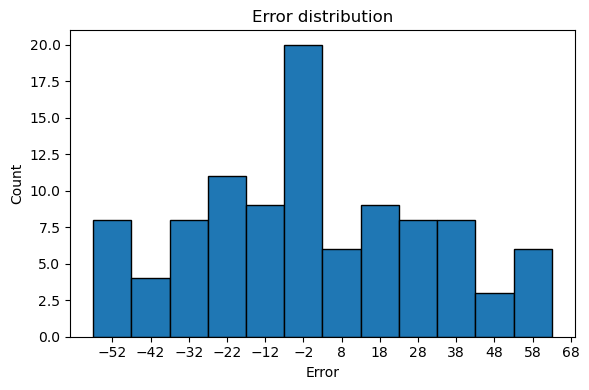

In [68]:
plot_error_histogram(results["errors"], model_name, out_dir, absolute=True)
plot_error_histogram(results["full_error"], model_name, out_dir, absolute=False)

Histogram is a great way to visualize error, but adding another one on top that is error instead of absolute error, to see if it tends to collapse upwards or downwards, maybe?